In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Enron_mini.csv')
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')
df['full_text'] = df['subject'] + " " + df['body']
df.head()

,subject,body,label,full_text
0,karthik rajan - interview schedule,attached you will find the interview packet fo...,0,karthik rajan - interview schedule attached yo...
1,re : a 3 al ad hoc review team,"in the week of the 25 th . , the 26 th and 27 ...",0,re : a 3 al ad hoc review team in the week of ...
2,not for sale in the u . a . e - usb voip hands...,not for sale in the u . a . e\r\nusb voip hand...,1,not for sale in the u . a . e - usb voip hands...
3,pharma,stop wasting money on prescription drugs . get...,1,pharma stop wasting money on prescription drug...
4,california update - - 10 . 02 . 01 : puc turns...,agreement with dwr\r\nin what will likely be v...,0,california update - - 10 . 02 . 01 : puc turns...


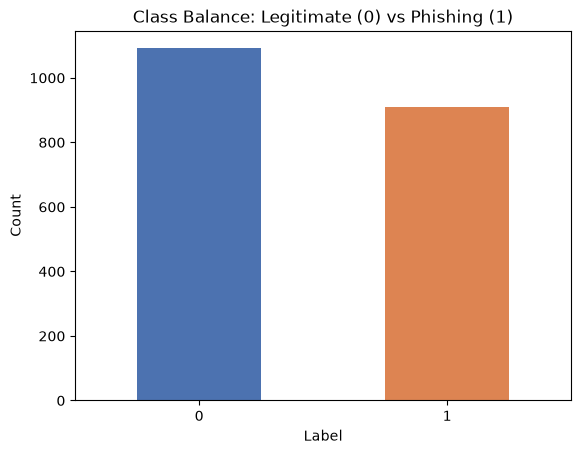

label
0    1091
1     909
Name: count, dtype: int64

In [2]:
df['label'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Class Balance: Legitimate (0) vs Phishing (1)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

df['label'].value_counts()

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

for label, name in [(0, 'Legitimate'), (1, 'Phishing')]:
    subset = df[df['label'] == label]['full_text']
    vec = CountVectorizer(stop_words='english', max_features=15)
    counts = vec.fit_transform(subset)
    freqs = counts.sum(axis=0).A1
    words = vec.get_feature_names_out()
    top = sorted(zip(words, freqs), key=lambda x: -x[1])
    print(f"\nTop words in {name} emails:")
    for word, freq in top:
        print(f"  {word}: {freq}")


Top words in Legitimate emails:
  enron: 3736
  ect: 1819
  2001: 1076
  2000: 885
  com: 836
  hou: 823
  subject: 818
  said: 691
  company: 684
  10: 664
  pm: 651
  vince: 641
  gas: 635
  energy: 621
  cc: 620

Top words in Phishing emails:
  com: 590
  company: 586
  email: 412
  http: 399
  statements: 391
  information: 373
  money: 314
  new: 299
  time: 297
  price: 288
  report: 286
  000: 285
  www: 270
  mail: 258
  just: 238
